## Andre marroquin
# Laboratorio #5

## Preparacion del entorno


In [ ]:
# se importan las librerias necesarias
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scapy.all import DNS, IP, Raw, TCP, UDP, rdpcap, sniff, wrpcap
from sklearn.ensemble import IsolationForest

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

ruta_pcap = Path("analisis_paquetes.pcap")
ruta_captura_temporal = Path("captura_prueba_scapy.pcap")

print("Archivo principal:", ruta_pcap)


Archivo principal: analisis_paquetes.pcap


## Parte 1 - analisis de paquetes

## Testeo de la herramienta

In [19]:
# se capturan 10 paquetes y se guardan en un nuevo pcap de prueba
paquetes_prueba = sniff(count=10)
nombre_pcap_prueba = "captura_10_paquetes.pcap"
wrpcap(nombre_pcap_prueba, paquetes_prueba)

print(f"Se capturaron {len(paquetes_prueba)} paquetes y se guardaron en {nombre_pcap_prueba}\n")

pcap_prueba = rdpcap(nombre_pcap_prueba)

print("=== Informacion general del pcap de prueba ===")
print("tipo de dato:", type(pcap_prueba))
print("cantidad de paquetes:", len(pcap_prueba))
print()

print("=== Contenido del pcap ===")
for indice_paquete, paquete_actual in enumerate(pcap_prueba, start=1):
    print(f"paquete {indice_paquete}")
    print("tipo de dato del paquete:", type(paquete_actual))
    print("longitud:", len(paquete_actual))
    print("contenido:")
    paquete_actual.show()
    print("-" * 60)

print("\n=== Valores de src_address, dst_address, src_port y dst_port ===")
print(f"{'no.':<5}{'src_address':<20}{'dst_address':<20}{'src_port':<12}{'dst_port':<12}")

# se guardan los datos extraidos en una lista
filas_prueba = []

for indice_paquete, paquete_actual in enumerate(pcap_prueba, start=1):
    src_address = paquete_actual[IP].src if IP in paquete_actual else "n/a"
    dst_address = paquete_actual[IP].dst if IP in paquete_actual else "n/a"

    if TCP in paquete_actual:
        src_port = paquete_actual[TCP].sport
        dst_port = paquete_actual[TCP].dport
    elif UDP in paquete_actual:
        src_port = paquete_actual[UDP].sport
        dst_port = paquete_actual[UDP].dport
    else:
        src_port = "n/a"
        dst_port = "n/a"

    filas_prueba.append(
        {
            "src_address": src_address,
            "dst_address": dst_address,
            "src_port": src_port,
            "dst_port": dst_port,
        }
    )

    print(f"{indice_paquete:<5}{src_address:<20}{dst_address:<20}{str(src_port):<12}{str(dst_port):<12}")

# se convierte la lista de diccionarios a un dataframe de pandas
tabla_prueba = pd.DataFrame(filas_prueba)
tabla_prueba

Se capturaron 10 paquetes y se guardaron en captura_10_paquetes.pcap

=== Informacion general del pcap de prueba ===
tipo de dato: <class 'scapy.plist.PacketList'>
cantidad de paquetes: 10

=== Contenido del pcap ===
paquete 1
tipo de dato del paquete: <class 'scapy.layers.l2.Ether'>
longitud: 54
contenido:
###[ Ethernet ]###
  dst       = 48:22:54:68:14:a6
  src       = 4c:49:6c:3a:e4:f4
  type      = IPv4
###[ IP ]###
     version   = 4
     ihl       = 5
     tos       = 0x0
     len       = 40
     id        = 62042
     flags     = DF
     frag      = 0
     ttl       = 128
     proto     = tcp
     chksum    = 0x7b00
     src       = 192.168.68.51
     dst       = 4.249.131.160
     \options   \
###[ TCP ]###
        sport     = 19551
        dport     = https
        seq       = 1986466615
        ack       = 615414530
        dataofs   = 5
        reserved  = 0
        flags     = A
        window    = 252
        chksum    = 0xa9fa
        urgptr    = 0
        options   = []


,src_address,dst_address,src_port,dst_port
0,192.168.68.51,4.249.131.160,19551,443
1,172.64.155.209,192.168.68.51,443,55888
2,192.168.68.51,172.64.155.209,55888,443
3,4.249.131.160,192.168.68.51,443,19551
4,4.249.131.160,192.168.68.51,443,19551
5,192.168.68.51,4.249.131.160,19551,443
6,4.249.131.160,192.168.68.51,443,19551
7,4.249.131.160,192.168.68.51,443,19551
8,192.168.68.51,4.249.131.160,19551,443
9,4.249.131.160,192.168.68.51,443,19551


## Carga del archivo real y conversion a dataframe
## Estadisticas Y deteccion 


In [ ]:
# se identifica el protocolo de cada paquete
def extraer_protocolo(paquete):
    if paquete.haslayer(DNS):
        return "DNS"
    if paquete.haslayer(TCP):
        return "TCP"
    if paquete.haslayer(UDP):
        return "UDP"
    if paquete.haslayer(IP):
        return "IP"
    return "OTRO"

# se obtienen los puertos solo si el paquete usa tcp o udp
def puertos_si_existen(paquete):
    if paquete.haslayer(TCP):
        return int(paquete[TCP].sport), int(paquete[TCP].dport)
    if paquete.haslayer(UDP):
        return int(paquete[UDP].sport), int(paquete[UDP].dport)
    return None, None

# se extrae el payload en bytes si existe una capa raw
def obtener_payload_bytes(paquete):
    if paquete.haslayer(Raw):
        return bytes(paquete[Raw].load)
    return b""

# se construtye una fila con los datos utiles del paquete
def fila_desde_paquete(indice, paquete):
    src_port, dst_port = puertos_si_existen(paquete)
    payload_bruto = obtener_payload_bytes(paquete)
    return {
        "indice": indice,
        "src_address": paquete[IP].src if paquete.haslayer(IP) else None,
        "dst_address": paquete[IP].dst if paquete.haslayer(IP) else None,
        "src_port": src_port,
        "dst_port": dst_port,
        "payload_len": len(payload_bruto),
        "pkt_len": len(bytes(paquete)),
        "protocolo": extraer_protocolo(paquete),
        "payload_hex": payload_bruto.hex(),
        "payload_ascii": payload_bruto.decode("utf-8", errors="replace"),
        "resumen": paquete.summary(),
    }

# se carga el archivo pcap real y construir un DataFrame con los datos de cada paquete
pcap_real = rdpcap(str(ruta_pcap))
df = pd.DataFrame([fila_desde_paquete(indice, paquete) for indice, paquete in enumerate(pcap_real)])

print("Cantidad total de paquetes:", len(df))
print("Columnas disponibles:", list(df.columns))

display(df.head(10))
display(df["protocolo"].value_counts().rename_axis("protocolo").reset_index(name="frecuencia"))


Cantidad total de paquetes: 62
Columnas disponibles: ['indice', 'src_address', 'dst_address', 'src_port', 'dst_port', 'payload_len', 'pkt_len', 'protocolo', 'payload_hex', 'payload_ascii', 'resumen']


,indice,src_address,dst_address,src_port,dst_port,payload_len,pkt_len,protocolo,payload_hex,payload_ascii,resumen
0,0,10.1.10.53,84.54.22.33,53,53,905,975,DNS,efbfbd504e470d0a1a0a0000000d494844520000016200...,�PNG\r\n\n   \rIHDR  b   �   (�TR  :�IDATx...,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
1,1,84.54.22.33,10.1.10.53,53,53,0,98,DNS,,,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...
2,2,10.1.10.53,84.54.22.33,53,53,919,989,DNS,3aefbfbd6c653ac7a9efbfbdefbfbdefbfbd0cefbfbdef...,:�le:ǩ��� ���:|�X��q.e���a0�J}4\n9$vz�R�uO/�...,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
3,3,84.54.22.33,10.1.10.53,53,53,0,98,DNS,,,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...
4,4,10.1.10.53,84.54.22.33,53,53,956,1026,DNS,efbfbdefbfbd5e6eefbfbd2727efbfbdefbfbdefbfbd24...,��^n�''���$�����R����>Epou��$��M�� ���tB\r�Ժ...,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
5,5,84.54.22.33,10.1.10.53,53,53,0,98,DNS,,,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...
6,6,10.1.10.53,84.54.22.33,53,53,942,1012,DNS,e48e91426a5fefbfbd610defbfbdefbfbdefbfbd04efbf...,䎑Bj_�a\r�����DJ�����B� B\r&�@�֞\t�D�o�gc...,Ether / IP / UDP / DNS Qry b'google.com.' / Raw
7,7,84.54.22.33,10.1.10.53,53,53,0,98,DNS,,,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...
8,8,10.1.10.53,84.54.22.33,53,53,947,1017,DNS,efbfbdefbfbdefbfbdcbb4efbfbd16efbfbdefbfbd726a...,"���˴���rj�GBWO��ݢi��0������e""3 Y\r\rP���^...",Ether / IP / UDP / DNS Qry b'google.com.' / Raw
9,9,84.54.22.33,10.1.10.53,53,53,0,98,DNS,,,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...


,protocolo,frecuencia
0,DNS,62


In [ ]:
# se obtienen las ips origen y destino mas frecuentes
top_src = df["src_address"].dropna().value_counts().rename_axis("src_address").reset_index(name="frecuencia")
top_dst = df["dst_address"].dropna().value_counts().rename_axis("dst_address").reset_index(name="frecuencia")

ip_origen_frecuente = top_src.loc[0, "src_address"]
ip_destino_frecuente = top_dst.loc[0, "dst_address"]

# se obtienen las ips destino con las que se comunica la ip origen mas frecuente
destinos_de_origen = (
    df[df["src_address"] == ip_origen_frecuente]["dst_address"]
    .dropna()
    .value_counts()
    .rename_axis("dst_address")
    .reset_index(name="frecuencia")
)

# se obtienen los puertos destino usados por la ip origen mas frecuente
puertos_destino_origen = (
    df[df["src_address"] == ip_origen_frecuente]["dst_port"]
    .dropna()
    .astype(int)
    .value_counts()
    .rename_axis("dst_port")
    .reset_index(name="frecuencia")
)

# se obtienen los puertos origen usados hacia la ip destino mas frecuente
puertos_origen_destino = (
    df[df["dst_address"] == ip_destino_frecuente]["src_port"]
    .dropna()
    .astype(int)
    .value_counts()
    .rename_axis("src_port")
    .reset_index(name="frecuencia")
)

display(top_src)
display(top_dst)
display(destinos_de_origen)
display(puertos_destino_origen)
display(puertos_origen_destino)


,src_address,frecuencia
0,10.1.10.53,31
1,84.54.22.33,29
2,75.75.75.75,2


,dst_address,frecuencia
0,10.1.10.53,31
1,84.54.22.33,29
2,75.75.75.75,2


,dst_address,frecuencia
0,84.54.22.33,29
1,75.75.75.75,2


,dst_port,frecuencia
0,53,31


,src_port,frecuencia
0,53,31


## Respuestas

### a. Muestre cual es la IP origen mas frecuente
**Respuesta:** Con base en los resultados obtenidos, la IP origen mas frecuente es 10.1.10.53 con 31 paquetes.

### b. Muestre cual es la IP destino mas frecuente
**Respuesta:** La IP destino mas frecuente tambien es 10.1.10.53 con 31 paquetes.

### c. A que IPs se comunica la IP del inciso a
**Respuesta:** La IP 10.1.10.53 se comunica principalmente con 84.54.22.33 (29), 75.75.75.75 (2). La conversacion dominante es con 84.54.22.33.

### d. A que puertos destino se comunica la IP del inciso a
**Respuesta:** En esta traza la IP 10.1.10.53 se comunica al puerto destino 53 (31).

### e. A que puertos origen se comunica la IP del inciso b
**Respuesta:** Cuando 10.1.10.53 aparece como destino, recibe trafico desde los puertos origen 53 (31). 

### f. Indique el proposito de los puertos que mas aparecen en los incisos d y e
**Respuesta:** El puerto 53 se usa normalmente para DNS, es decir, para resolver nombres de dominio. Lo llamativo aqui es que en la conversacion principal aparecen 53 -> 53 y ademas hay payloads binarios grandes.


## Z-score

Media de payload_len: 438.18
Desviacion estandar de payload_len: 470.62
Cantidad con |Z| > 2: 0
Cantidad con |Z| > 3: 0
Cantidad con z-score DNS por conocimiento de dominio: 62


,indice,src_address,dst_address,src_port,dst_port,payload_len,pkt_len,protocolo


,indice,src_address,dst_address,src_port,dst_port,payload_len,pkt_len,protocolo


,indice,src_address,dst_address,src_port,dst_port,payload_len,pkt_len,protocolo
0,0,10.1.10.53,84.54.22.33,53,53,905,975,DNS
1,1,84.54.22.33,10.1.10.53,53,53,0,98,DNS
2,2,10.1.10.53,84.54.22.33,53,53,919,989,DNS
3,3,84.54.22.33,10.1.10.53,53,53,0,98,DNS
4,4,10.1.10.53,84.54.22.33,53,53,956,1026,DNS
5,5,84.54.22.33,10.1.10.53,53,53,0,98,DNS
6,6,10.1.10.53,84.54.22.33,53,53,942,1012,DNS
7,7,84.54.22.33,10.1.10.53,53,53,0,98,DNS
8,8,10.1.10.53,84.54.22.33,53,53,947,1017,DNS
9,9,84.54.22.33,10.1.10.53,53,53,0,98,DNS


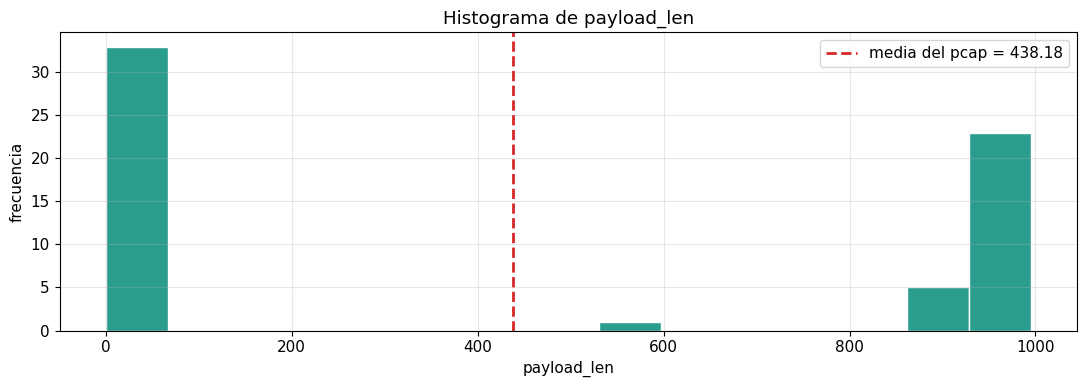

In [ ]:
# se calcula la media y desviacion estandar del payload
media_payload = df["payload_len"].mean()
desviacion_payload = df["payload_len"].std(ddof=0)

if desviacion_payload == 0:
    df["z_score_payload"] = 0.0
else:
    df["z_score_payload"] = (df["payload_len"] - media_payload) / desviacion_payload

# se calcula el z score usando valores de referencia para dns
media_dns = 50.0
desviacion_dns = 15.0
df["z_score_dns"] = (df["payload_len"] - media_dns) / desviacion_dns

# se filtran paquetes anomalos segun distintos umbrales
anomalias_z_2 = df[df["z_score_payload"].abs() > 2].copy()
anomalias_z_3 = df[df["z_score_payload"].abs() > 3].copy()
anomalias_dns = df[df["z_score_dns"].abs() > 2].copy()

print("Media de payload_len:", round(media_payload, 2))
print("Desviacion estandar de payload_len:", round(desviacion_payload, 2))
print("Cantidad con |Z| > 2:", len(anomalias_z_2))
print("Cantidad con |Z| > 3:", len(anomalias_z_3))
print("Cantidad con z-score DNS por conocimiento de dominio:", len(anomalias_dns))

display(anomalias_z_2[["indice", "src_address", "dst_address", "src_port", "dst_port", "payload_len", "pkt_len", "protocolo"]])
display(anomalias_z_3[["indice", "src_address", "dst_address", "src_port", "dst_port", "payload_len", "pkt_len", "protocolo"]])
display(anomalias_dns[["indice", "src_address", "dst_address", "src_port", "dst_port", "payload_len", "pkt_len", "protocolo"]].head(20))

plt.figure(figsize=(11, 4))
plt.hist(df["payload_len"], bins=15, color="#2a9d8f", edgecolor="white")
plt.axvline(media_payload, color="#d62828", linestyle="--", linewidth=2, label=f"media del pcap = {media_payload:.2f}")
plt.title("Histograma de payload_len")
plt.xlabel("payload_len")
plt.ylabel("frecuencia")
plt.legend()
plt.tight_layout()
plt.show()


## Respuestas

### a. Calcule el Z-score de la columna payload para todos los paquetes. Hay paquetes con |Z| > 2 o |Z| > 3? Muestre los resultados. Encontro paquetes anomalos?
**Respuesta:** No. Usando la media y la desviacion estandar del propio pcap, la media de payload_len fue 438.18 y la desviacion estandar fue 470.62. Con esos valores no aparecieron paquetes con |Z| > 2 ni con |Z| > 3, por lo que este z-score no detecto paquetes anomalos.

### b. Muestre un histograma de payload_len. La distribucion es normal? Si el Z-score no detecto anomalías, explique por que la forma de la distribucion causa este problema.
**Respuesta:** La distribucion no se ve normal. Es claramente bimodal: un grupo queda en 0 bytes y otro se concentra cerca de 900 a 1000 bytes. Como la media y la desviacion se calculan sobre esos dos grupos mezclados, el z-score termina absorbiendo el comportamiento raro dentro de la propia referencia y por eso no marca outliers.

### c. Ahora calcule el Z-score usando conocimiento de dominio: el tamano tipico de una consulta DNS es de aproximadamente 50 bytes con una desviacion estandar de 15 bytes. Utilice estos valores como la media y desviacion de referencia en lugar de calcularlos del pcap. Que paquetes se detectan ahora como anomalos? Cuantos paquetes fueron detectados?
**Respuesta:** Usando como referencia una consulta DNS tipica de 50 bytes con desviacion estandar de 15 bytes, se obtuvieron 62 paquetes fuera del rango esperado con |Z| > 2. Sin embargo, los paquetes mas sospechosos son los enviados de 10.1.10.53 hacia 84.54.22.33, ya que presentan payload_len de aproximadamente 905 a 989 bytes, valores demasiado altos para una consulta DNS normal. Los paquetes con payload_len = 0 tambien quedan fuera del rango, pero deben interpretarse con precaucion porque en este analisis payload_len corresponde a la capa Raw, no necesariamente al tamano total del mensaje DNS.

### d. Que puede decir que nos ensena esto sobre la importancia de conocer el o los protocolos a analizar al aplicar tecnicas de deteccion de anomalias?
**Respuesta:** El conocimiento del protocolo cambia por completo la interpretacion. Si solo se usa la estadistica interna del pcap, el trafico raro se normaliza. En cambio, cuando se compara contra lo esperable para DNS, el trafico resalta. Tambien no basta con conocer el protocolo, tambien hay que elegir bien la variable que se esta midiendo.


## Graficas


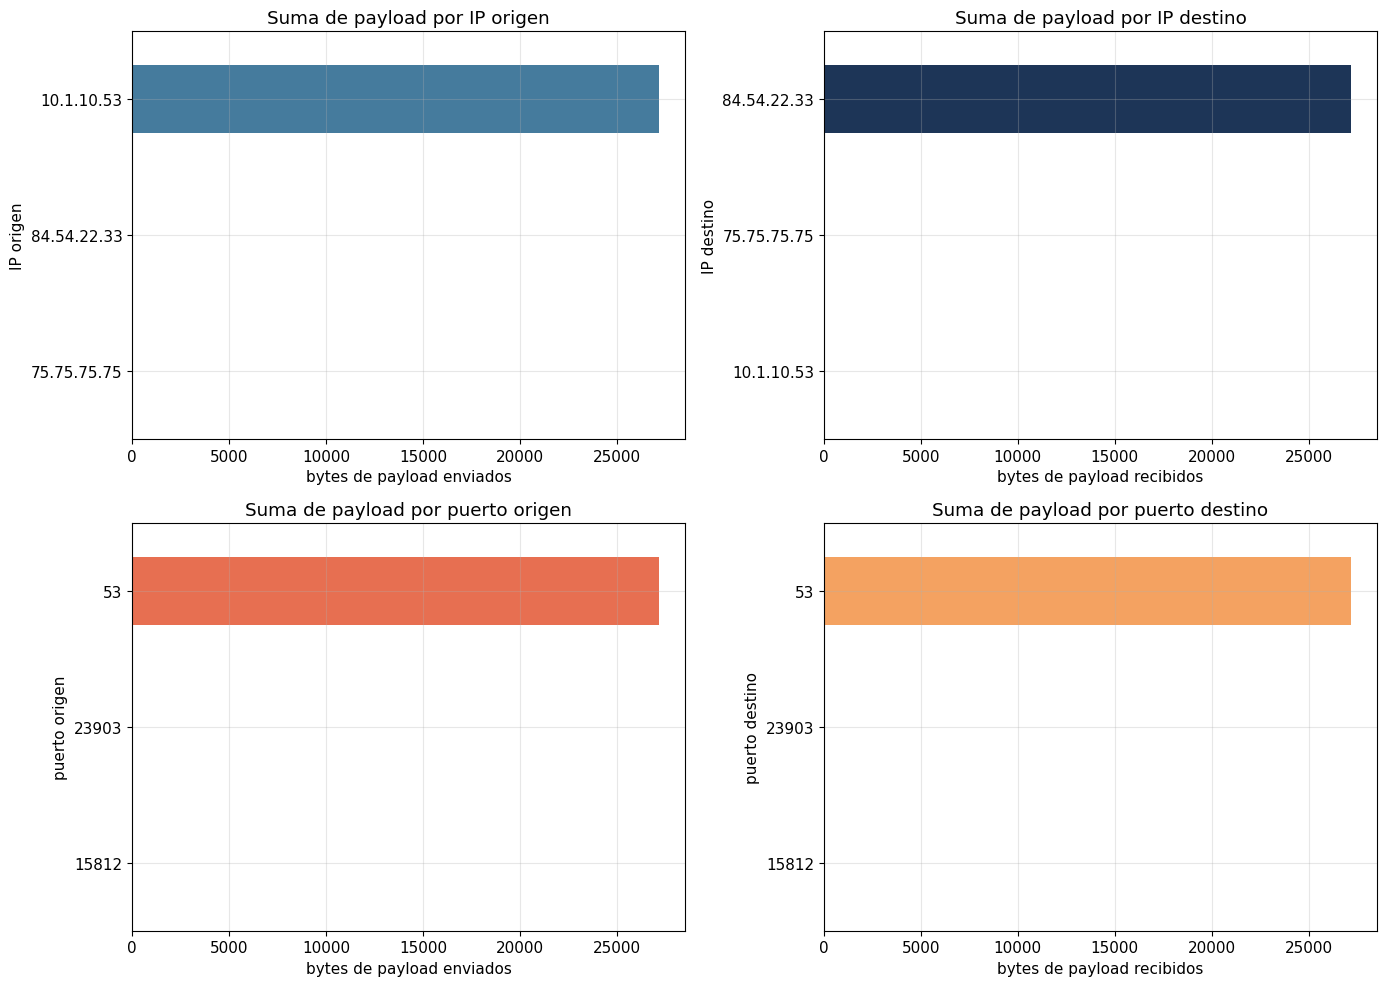

In [16]:
# se muestran las diferentes graficas de la suma de payloads por src, dst, sport y dport
suma_por_src = df.groupby(df["src_address"].fillna("sin_ip"))["payload_len"].sum().sort_values()
suma_por_dst = df.groupby(df["dst_address"].fillna("sin_ip"))["payload_len"].sum().sort_values()
suma_por_sport = df.groupby(df["src_port"].fillna(-1).astype(int))["payload_len"].sum().sort_values()
suma_por_dport = df.groupby(df["dst_port"].fillna(-1).astype(int))["payload_len"].sum().sort_values()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

suma_por_src.plot(kind="barh", ax=axes[0, 0], color="#457b9d")
axes[0, 0].set_title("Suma de payload por IP origen")
axes[0, 0].set_xlabel("bytes de payload enviados")
axes[0, 0].set_ylabel("IP origen")

suma_por_dst.plot(kind="barh", ax=axes[0, 1], color="#1d3557")
axes[0, 1].set_title("Suma de payload por IP destino")
axes[0, 1].set_xlabel("bytes de payload recibidos")
axes[0, 1].set_ylabel("IP destino")

suma_por_sport.plot(kind="barh", ax=axes[1, 0], color="#e76f51")
axes[1, 0].set_title("Suma de payload por puerto origen")
axes[1, 0].set_xlabel("bytes de payload enviados")
axes[1, 0].set_ylabel("puerto origen")

suma_por_dport.plot(kind="barh", ax=axes[1, 1], color="#f4a261")
axes[1, 1].set_title("Suma de payload por puerto destino")
axes[1, 1].set_xlabel("bytes de payload recibidos")
axes[1, 1].set_ylabel("puerto destino")

plt.tight_layout()
plt.show()


## Deteccion automatica con isolation forest

In [ ]:
# se calcula la tasa de contaminacion a partir de las anomalias dns
contaminacion = len(anomalias_dns) / len(df)
if contaminacion <= 0:
    contaminacion_modelo = max(1 / len(df), 0.001)
else:
    contaminacion_modelo = min(contaminacion, 0.5)

modelo_if = IsolationForest(
    n_estimators=200,
    contamination=contaminacion_modelo,
    random_state=42,
)

# se marcan las filas detectadas como anomalias
df["isolation_forest"] = modelo_if.fit_predict(df[["payload_len", "pkt_len"]])
df["anomalia_if"] = df["isolation_forest"] == -1
anomalias_if = df[df["anomalia_if"]].copy()

print("Contaminacion original:", round(contaminacion, 4))
print("Contaminacion ajustada para el modelo:", round(contaminacion_modelo, 4))
print("Cantidad de anomalias detectadas por Isolation Forest:", len(anomalias_if))

display(anomalias_if[["indice", "src_address", "dst_address", "src_port", "dst_port", "payload_len", "pkt_len", "protocolo"]])


Contaminacion original: 1.0
Contaminacion ajustada para el modelo: 0.5
Cantidad de anomalias detectadas por Isolation Forest: 30


,indice,src_address,dst_address,src_port,dst_port,payload_len,pkt_len,protocolo
0,0,10.1.10.53,84.54.22.33,53,53,905,975,DNS
2,2,10.1.10.53,84.54.22.33,53,53,919,989,DNS
4,4,10.1.10.53,84.54.22.33,53,53,956,1026,DNS
6,6,10.1.10.53,84.54.22.33,53,53,942,1012,DNS
8,8,10.1.10.53,84.54.22.33,53,53,947,1017,DNS
10,10,10.1.10.53,84.54.22.33,53,53,989,1059,DNS
12,12,10.1.10.53,84.54.22.33,53,53,952,1022,DNS
14,14,10.1.10.53,84.54.22.33,53,53,923,993,DNS
16,16,10.1.10.53,84.54.22.33,53,53,903,973,DNS
18,18,10.1.10.53,84.54.22.33,53,53,936,1006,DNS


## Respuestas

### a. Utilice las columnas numericas del DataFrame (payload_len y pkt_len) para entrenar un modelo de Isolation Forest con un valor igual al numero de paquetes detectados en el inciso 4c dividido por el numero de paquetes totales para definir su valor para el parametro contamination. Que paquetes son marcados como anomalías?
**Respuesta:** El valor de contaminacion calculado fue 1.0, pero Isolation Forest no permite usar un valor tan alto, ya que solo acepta valores entre 0 y 0.5. Por eso fue necesario ajustarlo a 0.5 para poder ejecutar el modelo. Con esp, el modelo marco 30 paquetes como anomalos. La mayoria pertenecen a la conversacion entre 10.1.10.53 y 84.54.22.33, que es justamente donde aparecen los payloads mas grandes y fuera de lo comun. Tambien se marcaron algunos paquetes del intercambio con 75.75.75.75.

### b. Las anomalias detectadas coinciden con las IPs o conversaciones sospechosas que identifico con los Z-score? Explique.
**Respuesta:** Si, coinciden en parte. Isolation Forest vuelve a resaltar la conversacion con 84.54.22.33, que ya habia aparecido como la mas sospechosa en el analisis con z-score. Sin embargo, no la separa de forma totalmente limpia, porque tambien incluye algunos paquetes de otro intercambio DNS que parecen menos relevantes. Esto muestra que el modelo sirve para orientar la investigacion y señalar donde vale la pena mirar, pero aun asi hace falta revisar manualmente el trafico para confirmar que realmente es sospechoso.


## Investigacion del payload

In [ ]:
# se filtran solo las conexiones cuya ip origen es la mas frecuente
df_origen_frecuente = df[df["src_address"] == ip_origen_frecuente].copy()

# se agrupan las conexiones por origen destino y payload para ver repeticiones y bytes totales
df_payload_agrupado = (
    df_origen_frecuente.groupby(["src_address", "dst_address", "payload_hex"], dropna=False)["payload_len"]
    .agg(["count", "sum"])
    .reset_index()
    .rename(columns={"count": "repeticiones", "sum": "bytes_totales"})
    .sort_values(["bytes_totales", "repeticiones"], ascending=False)
)

# se clacilan con que ip se intercambiaron mas bytes en total
intercambio_bytes = (
    df[
        (df["src_address"] == ip_origen_frecuente)
        | (df["dst_address"] == ip_origen_frecuente)
    ]
    .assign(
        ip_contraparte=lambda datos: np.where(
            datos["src_address"] == ip_origen_frecuente,
            datos["dst_address"],
            datos["src_address"],
        )
    )
    .groupby("ip_contraparte", dropna=False)["payload_len"]
    .sum()
    .sort_values(ascending=False)
    .rename_axis("ip_contraparte")
    .reset_index(name="payload_total")
)

# se toman la ip con mayor intercambio de bytes como ip sospechosa
ip_sospechosa = intercambio_bytes.loc[0, "ip_contraparte"]

# se filtran la conversacion entre la ip origen mas frecuente y la ip sospechosa
df_conversacion = df[
    (
        (df["src_address"] == ip_origen_frecuente)
        & (df["dst_address"] == ip_sospechosa)
    )
    | (
        (df["src_address"] == ip_sospechosa)
        & (df["dst_address"] == ip_origen_frecuente)
    )
].copy()

payloads_conversacion = [bytes.fromhex(payload_hex) for payload_hex in df_conversacion["payload_hex"] if payload_hex]
primer_payload = payloads_conversacion[0]

# se p[repara] una vista hexadecimal y una vista ascii del primer payload
def vista_hexadecimal(datos, limite=48):
    return " ".join(f"{byte:02x}" for byte in datos[:limite])
primer_payload_hex = vista_hexadecimal(primer_payload, limite=48)
primer_payload_ascii = primer_payload[:200].decode("utf-8", errors="replace")

# se crea un resumen auxiliar de paquetes dns para facilitar la inspeccion 
df_resumen_dns = pd.DataFrame(
    [
        {
            "indice": indice,
            "summary": paquete.summary(),
            "src_address": paquete[IP].src if paquete.haslayer(IP) else None,
            "dst_address": paquete[IP].dst if paquete.haslayer(IP) else None,
            "src_port": int(paquete[UDP].sport) if paquete.haslayer(UDP) else (int(paquete[TCP].sport) if paquete.haslayer(TCP) else None),
            "dst_port": int(paquete[UDP].dport) if paquete.haslayer(UDP) else (int(paquete[TCP].dport) if paquete.haslayer(TCP) else None),
            "payload_len": len(bytes(paquete[Raw].load)) if paquete.haslayer(Raw) else 0,
        }
        for indice, paquete in enumerate(pcap_real)
    ]
)

display(df_origen_frecuente.head())
display(df_payload_agrupado.head(10))
display(intercambio_bytes)
display(df_conversacion.head(10))
display(
    df_resumen_dns[
        (df_resumen_dns["src_address"].isin([ip_origen_frecuente, ip_sospechosa, "75.75.75.75"]))
        & (df_resumen_dns["dst_address"].isin([ip_origen_frecuente, ip_sospechosa, "75.75.75.75"]))
    ].head(12)
)

print("IP sospechosa:", ip_sospechosa)
print("Cantidad de filas en la conversacion:", len(df_conversacion))
print("Cantidad de payloads no vacios:", len(payloads_conversacion))
print("Primer payload en hexadecimal:")
print(primer_payload_hex)
print("\nPrimer payload con decodificacion segura:")
print(primer_payload_ascii)


,indice,src_address,dst_address,src_port,dst_port,payload_len,pkt_len,protocolo,payload_hex,payload_ascii,resumen,z_score_payload,z_score_dns,isolation_forest,anomalia_if
0,0,10.1.10.53,84.54.22.33,53,53,905,975,DNS,efbfbd504e470d0a1a0a0000000d494844520000016200...,�PNG\r\n\n   \rIHDR  b   �   (�TR  :�IDATx...,Ether / IP / UDP / DNS Qry b'google.com.' / Raw,0.991938,57.000000,-1,True
2,2,10.1.10.53,84.54.22.33,53,53,919,989,DNS,3aefbfbd6c653ac7a9efbfbdefbfbdefbfbd0cefbfbdef...,:�le:ǩ��� ���:|�X��q.e���a0�J}4\n9$vz�R�uO/�...,Ether / IP / UDP / DNS Qry b'google.com.' / Raw,1.021686,57.933333,-1,True
4,4,10.1.10.53,84.54.22.33,53,53,956,1026,DNS,efbfbdefbfbd5e6eefbfbd2727efbfbdefbfbdefbfbd24...,��^n�''���$�����R����>Epou��$��M�� ���tB\r�Ժ...,Ether / IP / UDP / DNS Qry b'google.com.' / Raw,1.100307,60.400000,-1,True
6,6,10.1.10.53,84.54.22.33,53,53,942,1012,DNS,e48e91426a5fefbfbd610defbfbdefbfbdefbfbd04efbf...,䎑Bj_�a\r�����DJ�����B� B\r&�@�֞\t�D�o�gc...,Ether / IP / UDP / DNS Qry b'google.com.' / Raw,1.070558,59.466667,-1,True
8,8,10.1.10.53,84.54.22.33,53,53,947,1017,DNS,efbfbdefbfbdefbfbdcbb4efbfbd16efbfbdefbfbd726a...,"���˴���rj�GBWO��ݢi��0������e""3 Y\r\rP���^...",Ether / IP / UDP / DNS Qry b'google.com.' / Raw,1.081183,59.800000,-1,True


,src_address,dst_address,payload_hex,repeticiones,bytes_totales
26,10.1.10.53,84.54.22.33,efbfbdefbfbdefbfbd3c3e7defbfbdefbfbdefbfbd25ef...,1,995
14,10.1.10.53,84.54.22.33,77efbfbd20efbfbd0252efbfbd1900efbfbd5e7fefbfbd...,1,989
2,10.1.10.53,84.54.22.33,1d39efbfbd15c6b8efbfbd0a63efbfbdefbfbd7b1befbf...,1,983
3,10.1.10.53,84.54.22.33,2a0befbfbdcbaaefbfbd66efbfbd75efbfbdefbfbdefbf...,1,981
7,10.1.10.53,84.54.22.33,4fefbfbdefbfbdefbfbdefbfbdc880efbfbdefbfbdefbf...,1,981
24,10.1.10.53,84.54.22.33,efbfbdefbfbd58efbfbdefbfbd09efbfbdf3bc89b7efbf...,1,979
20,10.1.10.53,84.54.22.33,efbfbd4befbfbd65efbfbd34efbfbd50244d1171efbfbd...,1,971
6,10.1.10.53,84.54.22.33,4c0c3eefbfbd372b2befbfbd727defbfbdefbfbd587fef...,1,963
11,10.1.10.53,84.54.22.33,72cc90207e16efbfbd00efbfbdefbfbd7fefbfbd02efbf...,1,961
17,10.1.10.53,84.54.22.33,7f30efbfbd3672efbfbd16efbfbd1e6142efbfbdefbfbd...,1,957


,ip_contraparte,payload_total
0,84.54.22.33,27167
1,75.75.75.75,0


,indice,src_address,dst_address,src_port,dst_port,payload_len,pkt_len,protocolo,payload_hex,payload_ascii,resumen,z_score_payload,z_score_dns,isolation_forest,anomalia_if
0,0,10.1.10.53,84.54.22.33,53,53,905,975,DNS,efbfbd504e470d0a1a0a0000000d494844520000016200...,�PNG\r\n\n   \rIHDR  b   �   (�TR  :�IDATx...,Ether / IP / UDP / DNS Qry b'google.com.' / Raw,0.991938,57.000000,-1,True
1,1,84.54.22.33,10.1.10.53,53,53,0,98,DNS,,,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...,-0.931071,-3.333333,1,False
2,2,10.1.10.53,84.54.22.33,53,53,919,989,DNS,3aefbfbd6c653ac7a9efbfbdefbfbdefbfbd0cefbfbdef...,:�le:ǩ��� ���:|�X��q.e���a0�J}4\n9$vz�R�uO/�...,Ether / IP / UDP / DNS Qry b'google.com.' / Raw,1.021686,57.933333,-1,True
3,3,84.54.22.33,10.1.10.53,53,53,0,98,DNS,,,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...,-0.931071,-3.333333,1,False
4,4,10.1.10.53,84.54.22.33,53,53,956,1026,DNS,efbfbdefbfbd5e6eefbfbd2727efbfbdefbfbdefbfbd24...,��^n�''���$�����R����>Epou��$��M�� ���tB\r�Ժ...,Ether / IP / UDP / DNS Qry b'google.com.' / Raw,1.100307,60.400000,-1,True
5,5,84.54.22.33,10.1.10.53,53,53,0,98,DNS,,,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...,-0.931071,-3.333333,1,False
6,6,10.1.10.53,84.54.22.33,53,53,942,1012,DNS,e48e91426a5fefbfbd610defbfbdefbfbdefbfbd04efbf...,䎑Bj_�a\r�����DJ�����B� B\r&�@�֞\t�D�o�gc...,Ether / IP / UDP / DNS Qry b'google.com.' / Raw,1.070558,59.466667,-1,True
7,7,84.54.22.33,10.1.10.53,53,53,0,98,DNS,,,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...,-0.931071,-3.333333,1,False
8,8,10.1.10.53,84.54.22.33,53,53,947,1017,DNS,efbfbdefbfbdefbfbdcbb4efbfbd16efbfbdefbfbd726a...,"���˴���rj�GBWO��ݢi��0������e""3 Y\r\rP���^...",Ether / IP / UDP / DNS Qry b'google.com.' / Raw,1.081183,59.800000,-1,True
9,9,84.54.22.33,10.1.10.53,53,53,0,98,DNS,,,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...,-0.931071,-3.333333,1,False


,indice,summary,src_address,dst_address,src_port,dst_port,payload_len
0,0,Ether / IP / UDP / DNS Qry b'google.com.' / Raw,10.1.10.53,84.54.22.33,53,53,905
1,1,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...,84.54.22.33,10.1.10.53,53,53,0
2,2,Ether / IP / UDP / DNS Qry b'google.com.' / Raw,10.1.10.53,84.54.22.33,53,53,919
3,3,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...,84.54.22.33,10.1.10.53,53,53,0
4,4,Ether / IP / UDP / DNS Qry b'google.com.' / Raw,10.1.10.53,84.54.22.33,53,53,956
5,5,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...,84.54.22.33,10.1.10.53,53,53,0
6,6,Ether / IP / UDP / DNS Qry b'google.com.' / Raw,10.1.10.53,84.54.22.33,53,53,942
7,7,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...,84.54.22.33,10.1.10.53,53,53,0
8,8,Ether / IP / UDP / DNS Qry b'google.com.' / Raw,10.1.10.53,84.54.22.33,53,53,947
9,9,Ether / IP / UDP / DNS Ans 2607:f8b0:4005:807:...,84.54.22.33,10.1.10.53,53,53,0


IP sospechosa: 84.54.22.33
Cantidad de filas en la conversacion: 58
Cantidad de payloads no vacios: 29
Primer payload en hexadecimal:
ef bf bd 50 4e 47 0d 0a 1a 0a 00 00 00 0d 49 48 44 52 00 00 01 62 00 00 00 ef bf bd 08 06 00 00 00 28 ef bf bd 54 52 00 00 3a ef bf bd 49 44 41

Primer payload con decodificacion segura:
�PNG

IHDR  b      (�TR  :�IDATx��	|T�����;K�
E��$��Ziߪ-�;N2��V�V�a�Z!��ܻik[�.ok�e�\��]�-���d��g��


## Respuestas

### a. Cree un nuevo DataFrame que incluya unicamente las conexiones con la direccion IP origen mas frecuente
**Respuesta:** Se creo `df_origen_frecuente` filtrando solo las filas con `src_address == "10.1.10.53"`.

### b. Obtenga un nuevo DataFrame con las columnas Src Address, Dst Address y agrupelas por payload
**Respuesta:** Se genero `df_payload_agrupado`, que resume origen, destino, `payload_hex`, repeticiones y bytes acumulados. Eso permite ver que la mayor parte del volumen sale hacia **84.54.22.33**.

### c. Obtenga la IP que mas ha intercambiado bytes con la IP mas frecuente. Confirme que esta es la misma IP sospechosa identificada por las tecnicas automaticas.
**Respuesta:** La IP que mas bytes intercambia con 10.1.10.53 es 84.54.22.33, con 27167 bytes de payload. Si, coincide con la conversacion que resaltaron el z-score con conocimiento de dominio y Isolation Forest.

### d. Cree un nuevo DataFrame con la conversacion entre la IP mas frecuente y la IP sospechosa
**Respuesta:** Se construyo `df_conversacion` filtrando ambos sentidos entre 10.1.10.53 y 84.54.22.33.

### e. Obtenga los payloads del DataFrame anterior y añada cada uno en un array
**Respuesta:** Los payloads se guardaron en la lista `payloads_conversacion`.

### f. Muestre el contenido del primer array
**Respuesta:** El primer payload se muestra en hexadecimal y en una decodificacion segura. Los primeros bytes observados fueron:

`ef bf bd 50 4e 47 0d 0a 1a 0a 00 00 00 0d 49 48 44 52 00 00 01 62 00 00 00 ef bf bd 08 06 00 00 00 28 ef bf bd 54 52 00 00 3a ef bf bd 49 44 41`

Y la vista textual segura empieza asi:

`�PNG

   
IHDR  b   �   (�TR  :�IDATx��	|T�����;K;�
E��$��Ziߪ-�;N2��V�V�a�Z!��ܻik[�.ok�e�\��]�-���d����g���<��L�$3wf��<_
�Y�r��y���

�8c�ew

�����iaK����u}Ųw�d���"`:�
�
��&�9Ɛ� `

### g. Examine los primeros bytes del contenido. Encuentra algun dato que no haga sentido que se envie a traves del puerto explicado en el inciso 3f? En que consiste el ataque detectado? Por que es importante combinar tecnicas automaticas con investigacion manual del payload?
**Respuesta:** Si. En los primeros bytes aparece informacion propia de un archivo PNG, lo cual no tiene sentido dentro de trafico DNS normal por el puerto 53. Eso sugiere que el canal DNS se esta usando para transportar datos binarios que no deberian ir ahi. Con base en esa evidencia, lo mas probable es que se trate de un caso de tunelizacion por DNS. Esta parte manual fue importante, porque las tecnicas automaticas ayudaron a señalar donde estaba el trafico raro, pero solo al revisar el contenido real del payload se pudo entender mejor que tipo de informacion se estaba moviendo y por que era sospechosa.
